# Audio-to-Image Generation Pipeline

## Overview
This pipeline generates images from audio inputs and is split into 4 phases:

**Phase 0: Setup** - Mount drive, imports, dataset etc

**Phase 1: MLP Training** - Train an adapter to map CLAP audio embeddings to Stable Diffusion's text embedding space

**Phase 2: LoRA Fine-tuning** - Fine-tune Stable Diffusion on domain-specific images (bird sounds → bird images)

**Phase 3: Inference** - I run the inference on before and after finetuning, both using the same MLP projected embeddings

**Phase 4: CLIP Evaluation** - Measure image-text alignment using CLIP Score

## Main idea
```
Audio → CLAP → MLP Adapter → Stable Diffusion (LoRA) → Image
```

## Goal
Generate images from audio and quantify performance improvements from domain-specific fine-tuning.


# Phase 0: Setup & Data Prep

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:

!pip install transformers torch pandas librosa soundfile open_clip_torch
!pip install diffusers accelerate
!pip install laion-clap

In [3]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import librosa
import open_clip
from transformers import CLIPTokenizer, CLIPTextModel
from PIL import Image
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Check for GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [4]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

try:

    csv_path = "/content/drive/MyDrive/audio_to_image_project/main_dataV1(in).csv"

    df = pd.read_csv(csv_path)

    print("CSV loaded successfully. Here's the .info():")
    print(df.info())

    print("\nHere's the .head() (first 5 rows):")
    print(df.head())

except Exception as e:
    print(f"Error loading CSV: {e}")
    print("\nPlease double-check the 'csv_path' variable to make sure it matches the exact location in your Google Drive.")

CSV loaded successfully. Here's the .info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18643 entries, 0 to 18642
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   base_folder  18643 non-null  object
 1   image_file   18643 non-null  object
 2   audio_file   18643 non-null  object
 3   caption      18643 non-null  object
dtypes: object(4)
memory usage: 582.7+ KB
None

Here's the .head() (first 5 rows):
   base_folder         image_file            audio_file                caption
0  vggsound_00     g-f_I2yQ_1.png   g-f_I2yQ_000001.wav        people marching
1  vggsound_00   0PQM4-hqg_30.png  0PQM4-hqg_000030.wav     waterfall burbling
2  vggsound_00  56QUhyDQM_185.png  56QUhyDQM_000185.wav         playing tennis
3  vggsound_00   5OkAjCI7g_40.png  5OkAjCI7g_000040.wav  people belly laughing
4  vggsound_00   8puiAGLhs_30.png  8puiAGLhs_000030.wav    car engine starting


In [5]:

# import os

# # --- Path Definitions ---
# DRIVE_PROJECT_ROOT = "/content/drive/MyDrive/audio_to_image_project"
# ZIP_FILE_PATH = os.path.join(DRIVE_PROJECT_ROOT, "vggsound.zip")
# AUDIO_ROOT = os.path.join(DRIVE_PROJECT_ROOT, "vggsound")

# # --- Unzip Command ---
# # We use '-n' to avoid re-unzipping files if you've already run this.
# # We use '-d' to specify the destination directory.
# print("Unzipping audio files... This may take a while.")

# !unzip -n "{ZIP_FILE_PATH}" -d "{AUDIO_ROOT}"

# print("Unzipping complete.")

## Define File Paths and Columns

In [6]:

# --- Path and Column Definitions ---

# The main project folder in Google Drive
DRIVE_PROJECT_ROOT = "/content/drive/MyDrive/audio_to_image_project"

# The path to audio folder
# This folder should contain all 18k+ .wav files
AUDIO_ROOT = os.path.join(DRIVE_PROJECT_ROOT, "vggsound")

# The path to CSV file
CSV_PATH = os.path.join(DRIVE_PROJECT_ROOT, "main_dataV1(in).csv")

# Column names from CSV
AUDIO_FILE_COL = "audio_file"
CAPTION_COL = "caption"

## Create the Audio-Text Dataset

In [7]:
import soundfile as sf

class AudioTextDataset(Dataset):
    def __init__(self, csv_path, audio_root, audio_file_col, caption_col):
        self.df = pd.read_csv(csv_path)
        self.audio_root = audio_root
        self.audio_file_col = audio_file_col
        self.caption_col = caption_col

        # CLAP model's target sample rate
        self.target_sample_rate = 48000

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # 1. Get the row
        row = self.df.iloc[idx]

        # 2. Get caption
        caption = row[self.caption_col]

        # 3. Construct full audio path (Simpler!)
        audio_file = row[self.audio_file_col]
        audio_path = os.path.join(self.audio_root, audio_file)

        try:
            # 4. Load and resample audio
            waveform, sr = sf.read(audio_path, dtype='float32')

            # Convert to mono if it's stereo
            if waveform.ndim > 1:
                waveform = waveform.mean(axis=1)

            # Resample if necessary
            if sr != self.target_sample_rate:
                waveform = librosa.resample(waveform, orig_sr=sr, target_sr=self.target_sample_rate)

            # Convert to a PyTorch tensor
            audio_tensor = torch.tensor(waveform)

            return audio_tensor, caption

        except Exception as e:
            print(f"Error loading audio file {audio_path}: {e}")
            # Return None for this item if it fails
            return None, None

# --- Test the Dataset (Optional but Recommended) ---

print("Initializing dataset...")
# Create an instance of our dataset
dataset = AudioTextDataset(
    csv_path=CSV_PATH,
    audio_root=AUDIO_ROOT,
    audio_file_col=AUDIO_FILE_COL,
    caption_col=CAPTION_COL
)

print(f"Dataset length: {len(dataset)}")

# Try loading the first item
print("\nTesting item at index 0:")
audio, text = dataset[0]

if audio is not None:
    print(f"  Audio tensor shape: {audio.shape}")
    print(f"  Audio tensor dtype: {audio.dtype}")
    print(f"  Caption: {text}")
else:
    print("  Failed to load item 0. Check your file paths and folder structure.")

Initializing dataset...
Dataset length: 18643

Testing item at index 0:
  Audio tensor shape: torch.Size([482401])
  Audio tensor dtype: torch.float32
  Caption: people marching


# Phase 1: MLP Training

In [11]:
from transformers import ClapModel, AutoProcessor

print("Loading CLAP model...")
clap_model = ClapModel.from_pretrained("laion/clap-htsat-fused").to(device)
clap_processor = AutoProcessor.from_pretrained("laion/clap-htsat-fused")

# Freeze CLAP
clap_model.eval()
for param in clap_model.parameters():
    param.requires_grad = False

print(f"✓ CLAP model loaded on {device}")


# 2. SD Text Encoder - for target embeddings
from transformers import CLIPTextModel, CLIPTokenizer

print("Loading Stable Diffusion text encoder...")
SD_MODEL_ID = "runwayml/stable-diffusion-v1-5"

sd_tokenizer = CLIPTokenizer.from_pretrained(SD_MODEL_ID, subfolder="tokenizer")
sd_text_encoder = CLIPTextModel.from_pretrained(SD_MODEL_ID, subfolder="text_encoder").to(device)

# Freeze SD text encoder
sd_text_encoder.eval()
for param in sd_text_encoder.parameters():
    param.requires_grad = False

print(f"✓ SD text encoder loaded on {device}")
print(f"  Hidden size: {sd_text_encoder.config.hidden_size}")

Loading CLAP model...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/614M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/537 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/617 [00:00<?, ?B/s]

text_encoder/model.safetensors:   0%|          | 0.00/492M [00:00<?, ?B/s]

✓ SD text encoder loaded on cuda
  Hidden size: 768


In [12]:
class MlpAdapter(nn.Module):
    """
    MLP that projects CLAP audio embeddings to SD text encoder space
    With GELU activation
    """
    def __init__(self, input_dim=512, output_dim=768, hidden_dim=1024):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),  # Using GELU
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.layers(x)

# Instantiate the MLP
mlp_adapter = MlpAdapter(input_dim=512, output_dim=768).to(device)
print(f"✓ MLP adapter initialized on {device}")

✓ MLP adapter initialized on cuda


In [154]:
def collate_fn(batch):
    """
    Collate function that prepares:
    - Audio inputs for CLAP
    - Text captions (raw strings) for SD text encoder
    """
    # Filter out failed items
    batch = [item for item in batch if item[0] is not None]
    if not batch:
        return None, None

    # Separate audio and captions
    audio_tensors, captions = zip(*batch)

    # Convert audio to numpy arrays for CLAP processor
    raw_audio = [audio.numpy() for audio in audio_tensors]

    # Process audio with CLAP processor
    audio_inputs = clap_processor(
        audios=raw_audio,
        sampling_rate=48000,
        return_tensors="pt",
        padding=True
    )

    # Return audio inputs and raw captions
    return audio_inputs, list(captions)

In [155]:
BATCH_SIZE = 64

print("Creating DataLoader...")

# Using the dataset we created earlier
train_loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0
)

print(f"✓ DataLoader ready")
print(f"  Total samples: {len(dataset)}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Number of batches: {len(train_loader)}")

Creating DataLoader...
✓ DataLoader ready
  Total samples: 18643
  Batch size: 64
  Number of batches: 292


In [156]:
import torch.nn.functional as F
from tqdm.notebook import tqdm

# Hyperparameters
LEARNING_RATE = 2e-4
EPOCHS = 20
WEIGHT_DECAY = 1e-4

# Save path
ADAPTER_SAVE_PATH = os.path.join(DRIVE_PROJECT_ROOT, "MLP.pth")

# Optimizer - only MLP parameters (no logit_scale)
optimizer = optim.AdamW(
    mlp_adapter.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Loss tracking
epoch_losses = []
epoch_similarities = []

print(f"\n{'='*60}")
print(f"Starting MLP Training")
print(f"{'='*60}")
print(f"Loss: MSE (not contrastive)")
print(f"Target: SD text encoder embeddings")
print(f"Epochs: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"{'='*60}\n")



Starting MLP Training
Loss: MSE (not contrastive)
Target: SD text encoder embeddings
Epochs: 20
Learning rate: 0.0002
Batch size: 64



In [13]:
for epoch in range(1, EPOCHS + 1):
    mlp_adapter.train()

    epoch_loss = 0.0
    epoch_sim = 0.0
    num_batches = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")

    for audio_inputs, captions in pbar:
        if audio_inputs is None:  # Skip empty batches
            continue

        # Move audio inputs to device
        audio_inputs = {k: v.to(device) for k, v in audio_inputs.items()}

        # STEP 1: Get audio embeddings from CLAP (frozen)
        with torch.no_grad():
            audio_embeddings = clap_model.get_audio_features(**audio_inputs)
        # Shape: [batch_size, 512]

        # STEP 2: Get target embeddings from SD text encoder (frozen)
        with torch.no_grad():
            # Tokenize captions with SD tokenizer
            text_inputs = sd_tokenizer(
                captions,
                padding="max_length",
                max_length=sd_tokenizer.model_max_length,
                truncation=True,
                return_tensors="pt"
            ).to(device)

            # Get embeddings from SD text encoder
            outputs = sd_text_encoder(text_inputs.input_ids)

            # Use pooler_output (the [CLS] token embedding)
            # This is what SD uses for conditioning
            if hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None:
                sd_embeddings = outputs.pooler_output
            else:
                # Fallback: mean pooling of last hidden state
                sd_embeddings = outputs.last_hidden_state.mean(dim=1)
        # Shape: [batch_size, 768]

        # STEP 3: Project audio embeddings through MLP
        projected_embeddings = mlp_adapter(audio_embeddings)
        # Shape: [batch_size, 768]

        # STEP 4: Compute MSE loss
        loss = F.mse_loss(projected_embeddings, sd_embeddings)

        # STEP 5: Compute cosine similarity for monitoring
        with torch.no_grad():
            similarity = F.cosine_similarity(
                projected_embeddings,
                sd_embeddings,
                dim=-1
            ).mean()

        # STEP 6: Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(mlp_adapter.parameters(), max_norm=1.0)

        optimizer.step()

        # Track metrics
        epoch_loss += loss.item()
        epoch_sim += similarity.item()
        num_batches += 1

        # Update progress bar
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'sim': f'{similarity.item():.3f}'
        })

    # Epoch summary
    avg_loss = epoch_loss / num_batches
    avg_sim = epoch_sim / num_batches

    epoch_losses.append(avg_loss)
    epoch_similarities.append(avg_sim)

    print(f"\n{'='*60}")
    print(f"Epoch {epoch}/{EPOCHS} Summary:")
    print(f"  Average Loss: {avg_loss:.4f}")
    print(f"  Average Similarity: {avg_sim:.3f}")
    print(f"{'='*60}\n")

    # Save checkpoint
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': mlp_adapter.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_loss,
        'similarity': avg_sim,
        'config': {
            'input_dim': 512,
            'output_dim': 768,
            'hidden_dim': 1024
        }
    }

    torch.save(checkpoint, ADAPTER_SAVE_PATH)
    print(f"✓ Checkpoint saved to {ADAPTER_SAVE_PATH}\n")

print("\n" + "="*60)
print("TRAINING COMPLETED!")
print("="*60)


Epoch 1/20:   0%|          | 0/292 [00:00<?, ?it/s]


Epoch 1/20 Summary:
  Average Loss: 0.6867
  Average Similarity: 0.595

✓ Checkpoint saved to /content/drive/MyDrive/audio_to_image_project/MLP.pth



Epoch 2/20:   0%|          | 0/292 [00:00<?, ?it/s]


Epoch 2/20 Summary:
  Average Loss: 0.5802
  Average Similarity: 0.670

✓ Checkpoint saved to /content/drive/MyDrive/audio_to_image_project/MLP.pth



Epoch 3/20:   0%|          | 0/292 [00:00<?, ?it/s]

...


Epoch 18/20 Summary:
  Average Loss: 0.3501
  Average Similarity: 0.815

✓ Checkpoint saved to /content/drive/MyDrive/audio_to_image_project/MLP.pth



Epoch 19/20:   0%|          | 0/292 [00:00<?, ?it/s]


Epoch 19/20 Summary:
  Average Loss: 0.3455
  Average Similarity: 0.818

✓ Checkpoint saved to /content/drive/MyDrive/audio_to_image_project/MLP.pth



Epoch 20/20:   0%|          | 0/292 [00:00<?, ?it/s]


Epoch 20/20 Summary:
  Average Loss: 0.3410
  Average Similarity: 0.820

✓ Checkpoint saved to /content/drive/MyDrive/audio_to_image_project/MLP.pth


TRAINING COMPLETED!


✓ Training curves saved to /content/drive/MyDrive/audio_to_image_project/mlp_training.png


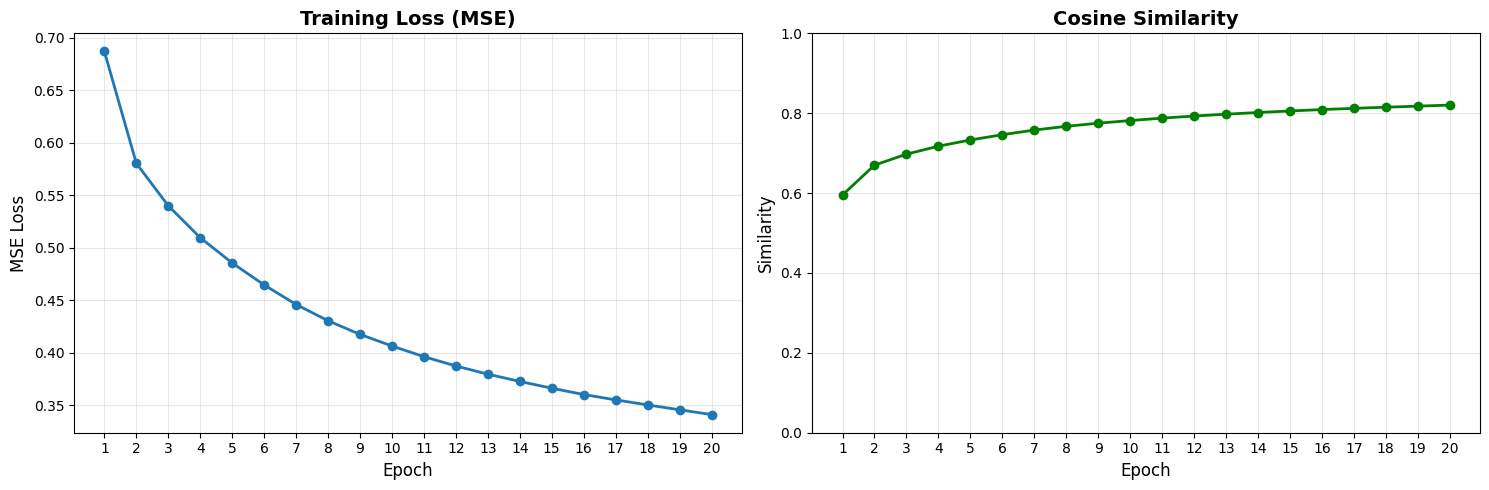

In [14]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss curve
ax1.plot(epoch_losses, marker='o', linestyle='-', linewidth=2)
ax1.set_title('Training Loss (MSE)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('MSE Loss', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(len(epoch_losses)))
ax1.set_xticklabels(range(1, len(epoch_losses) + 1))

# Similarity curve
ax2.plot(epoch_similarities, marker='o', linestyle='-', linewidth=2, color='green')
ax2.set_title('Cosine Similarity', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Similarity', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(len(epoch_similarities)))
ax2.set_xticklabels(range(1, len(epoch_similarities) + 1))
ax2.set_ylim([0, 1])

plt.tight_layout()

# Save plot
plot_path = os.path.join(DRIVE_PROJECT_ROOT, "mlp_training.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"✓ Training curves saved to {plot_path}")

plt.show()

In [15]:
print("\n" + "="*60)
print("MODEL TRAINING SUMMARY")
print("="*60)
print(f"Approach: Single-phase MSE training")
print(f"Final Loss: {epoch_losses[-1]:.4f}")
print(f"Final Similarity: {epoch_similarities[-1]:.3f}")
print(f"Model saved: {ADAPTER_SAVE_PATH}")
print(f"\nNext steps:")
print(f"  1. This model is ready for inference")
print(f"  2. NO LoRA training needed")
print(f"  3. Use with frozen Stable Diffusion")
print("="*60)


MODEL TRAINING SUMMARY
Approach: Single-phase MSE training
Final Loss: 0.3410
Final Similarity: 0.820
Model saved: /content/drive/MyDrive/audio_to_image_project/MLP.pth

Next steps:
  1. This model is ready for inference
  2. NO LoRA training needed
  3. Use with frozen Stable Diffusion


## Inference test for MLP

In [16]:
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

print("Loading Stable Diffusion pipeline for inference...")
pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16,
    safety_checker=None
).to(device)

print("✓ Stable Diffusion loaded\n")

# MLP is in eval mode
mlp_adapter.eval()

Loading Stable Diffusion pipeline for inference...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


✓ Stable Diffusion loaded



MlpAdapter(
  (layers): Sequential(
    (0): Linear(in_features=512, out_features=1024, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=1024, out_features=1024, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=1024, out_features=768, bias=True)
  )
)

In [24]:
@torch.no_grad()
def generate_image_from_audio(audio_tensor, base_prompt="A photo of", guidance_scale=7.5, num_steps=50):
    """
    Generate an image from an audio tensor
    """
    # Convert audio tensor to numpy for CLAP processor
    audio_numpy = audio_tensor.numpy()

    # Process audio with CLAP
    audio_inputs = clap_processor(
        audios=[audio_numpy],
        sampling_rate=48000,
        return_tensors="pt",
        padding=True
    )
    audio_inputs = {k: v.to(device) for k, v in audio_inputs.items()}

    # Get audio embeddings from CLAP
    audio_embeddings = clap_model.get_audio_features(**audio_inputs)

    # Project to SD text encoder space using trained MLP
    soft_token = mlp_adapter(audio_embeddings)

    # Tokenize base prompt
    text_inputs = pipe.tokenizer(
        base_prompt,
        padding="max_length",
        max_length=pipe.tokenizer.model_max_length,
        truncation=True,
        return_tensors="pt"
    ).to(device)

    # Get text encoder embeddings
    text_encoder_output = pipe.text_encoder(text_inputs.input_ids)[0]

    # Insert audio soft token after the last real token
    attention_mask = text_inputs.attention_mask[0]
    last_token_pos = attention_mask.nonzero(as_tuple=False).max().item()

    # Insert soft token
    if last_token_pos + 1 < text_encoder_output.shape[1]:
        text_encoder_output[0, last_token_pos + 1:last_token_pos + 2, :] = soft_token
    else:
        text_encoder_output[0, last_token_pos:last_token_pos + 1, :] = soft_token

    # Generate image
    image = pipe(
        prompt_embeds=text_encoder_output,
        num_inference_steps=num_steps,
        guidance_scale=guidance_scale
    ).images[0]

    return image

In [25]:
import random

print("="*60)
print("GENERATING TEST IMAGES FROM RANDOM SAMPLES")
print("="*60)

# Number of samples to test
NUM_SAMPLES = 3

# Pick 3 random indices from the dataset
random_indices = random.sample(range(len(dataset)), NUM_SAMPLES)
print(f"\nRandomly selected indices: {random_indices}\n")

# Get test samples
test_samples = []
for idx in random_indices:
    audio, caption = dataset[idx]
    if audio is not None:
        test_samples.append((audio, caption, idx))

print(f"Generating {len(test_samples)} images...\n")

# Generate images
generated_images = []
captions = []
indices = []

for audio, caption, idx in test_samples:
    print(f"Sample Index: {idx}")
    print(f"  Caption: {caption}")

    try:
        image = generate_image_from_audio(
            audio,
            base_prompt="A photo of",
            guidance_scale=7.5,
            num_steps=50
        )
        generated_images.append(image)
        captions.append(caption)
        indices.append(idx)
        print("  ✓ Generated successfully\n")
    except Exception as e:
        print(f"  ✗ Error: {e}\n")

GENERATING TEST IMAGES FROM RANDOM SAMPLES

Randomly selected indices: [6532, 7083, 3447]

Generating 3 images...

Sample Index: 6532
  Caption: scuba diving


  0%|          | 0/50 [00:00<?, ?it/s]

  ✓ Generated successfully

Sample Index: 7083
  Caption: playing bass guitar


  0%|          | 0/50 [00:00<?, ?it/s]

  ✓ Generated successfully

Sample Index: 3447
  Caption: machine gun shooting


  0%|          | 0/50 [00:00<?, ?it/s]

  ✓ Generated successfully



DISPLAYING RESULTS

✓ Results saved to /content/drive/MyDrive/audio_to_image_project/test_results_5epochs.png


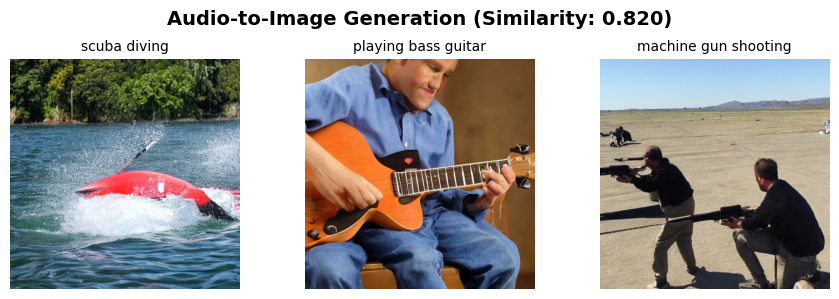


TESTING COMPLETED!
Final training metrics:
  Loss: 0.3410
  Similarity: 0.820

If results look poor/blurry, consider training 10-15 more epochs
to reach similarity > 0.85


In [26]:
print("="*60)
print("DISPLAYING RESULTS")
print("="*60)

fig, axes = plt.subplots(1, len(generated_images), figsize=(3*len(generated_images), 3))

if len(generated_images) == 1:
    axes = [axes]

for idx, (img, cap) in enumerate(zip(generated_images, captions)):
    axes[idx].imshow(img)
    # Wrap long captions
    wrapped_caption = cap[:60] + "..." if len(cap) > 60 else cap
    axes[idx].set_title(wrapped_caption, fontsize=10)
    axes[idx].axis('off')

plt.suptitle(f"Audio-to-Image Generation (Similarity: {epoch_similarities[-1]:.3f})",
             fontsize=14, fontweight='bold')
plt.tight_layout()

# Save results
results_path = os.path.join(DRIVE_PROJECT_ROOT, "test_results_5epochs.png")
plt.savefig(results_path, dpi=150, bbox_inches='tight')
print(f"\n✓ Results saved to {results_path}")

plt.show()

print("\n" + "="*60)
print("TESTING COMPLETED!")
print("="*60)
print(f"Final training metrics:")
print(f"  Loss: {epoch_losses[-1]:.4f}")
print(f"  Similarity: {epoch_similarities[-1]:.3f}")
print(f"\nIf results look poor/blurry, consider training 10-15 more epochs")
print(f"to reach similarity > 0.85")
print("="*60)

#Phase 2: Finetuning Stable Diffusion with LoRA

In [157]:
!pip install peft

In [158]:
# Cell 9: Load CLAP (audio) + CLIP (text)
import torch
from transformers import ClapModel, AutoProcessor, CLIPTokenizer, CLIPTextModel

print("Loading frozen CLAP (audio) and CLIP (text) models...")

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1) CLAP audio encoder (frozen)
CLAP_ID = "laion/clap-htsat-unfused"
clap_model = ClapModel.from_pretrained(CLAP_ID).to(device).eval()
clap_processor = AutoProcessor.from_pretrained(CLAP_ID)

# 2) CLIP text encoder (frozen, ViT-L/14 => 768-dim text embeds)
CLIP_ID = "openai/clip-vit-large-patch14"
clip_tokenizer = CLIPTokenizer.from_pretrained(CLIP_ID)
clip_text_model = CLIPTextModel.from_pretrained(CLIP_ID).to(device).eval()

print("Models loaded.")

# Quick smoke test
print("Running a quick smoke test...")
try:
    with torch.no_grad():
        toks = clip_tokenizer(["test"], padding=True, truncation=True, return_tensors="pt").to(device)
        text_out = clip_text_model(**toks)
        text_embeds = text_out.pooler_output
    print("CLIP Tokenizer and Model test... SUCCESS.")
except Exception as e:
    print(f"Error during smoke test: {e}")

Loading frozen CLAP (audio) and CLIP (text) models...
Models loaded.
Running a quick smoke test...
CLIP Tokenizer and Model test... SUCCESS.


In [159]:
# import os

# # --- Define Paths ---
# DRIVE_PROJECT_ROOT = "/content/drive/MyDrive/audio_to_image_project"
# NEW_ZIP_PATH = os.path.join(DRIVE_PROJECT_ROOT, "vggsound_bird.zip")
# NEW_DATA_ROOT = os.path.join(DRIVE_PROJECT_ROOT, "vggsound_bird")

# # --- Unzip Command ---
# print(f"Unzipping {NEW_ZIP_PATH} to {NEW_DATA_ROOT}...")
# # We use '-n' to avoid re-unzipping files if you've already run this.
# # We use '-d' to specify the destination directory.
# !unzip -n "{NEW_ZIP_PATH}" -d "{NEW_DATA_ROOT}"
# print("Unzipping complete.")

In [160]:
import pandas as pd
import os

# Define Paths
DRIVE_PROJECT_ROOT = "/content/drive/MyDrive/audio_to_image_project"
NEW_CSV_PATH = os.path.join(DRIVE_PROJECT_ROOT, "bird_sounds_filtered.csv")

# Inspect the new CSV file
print(f"\n--- Inspecting {NEW_CSV_PATH} ---")
try:
    bird_df = pd.read_csv(NEW_CSV_PATH)

    print("CSV loaded successfully. Here's the .info():")
    print(bird_df.info())

    print("\nHere's the .head() (first 5 rows):")
    print(bird_df.head())

    print("\n--- End of CSV Inspection ---")

except FileNotFoundError:
    print(f"Error: File not found at {NEW_CSV_PATH}")
    print("Please make sure the file 'bird_sounds_filtered.csv' is in your 'audio_to_image_project' folder.")
except Exception as e:
    print(f"An error occurred: {e}")


--- Inspecting /content/drive/MyDrive/audio_to_image_project/bird_sounds_filtered.csv ---
CSV loaded successfully. Here's the .info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 832 entries, 0 to 831
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   base_folder  832 non-null    object
 1   image_file   832 non-null    object
 2   audio_file   832 non-null    object
 3   caption      832 non-null    object
dtypes: object(4)
memory usage: 26.1+ KB
None

Here's the .head() (first 5 rows):
   base_folder           image_file              audio_file  \
0  vggsound_00   NxXwo4AR4M_142.png   NxXwo4AR4M_000142.wav   
1  vggsound_02    6aVD7uPvGmU_0.png  6aVD7uPvGmU_000000.wav   
2  vggsound_02    5aTwB99GEBU_0.png  5aTwB99GEBU_000000.wav   
3  vggsound_04    AKmkhvb9shk_0.png  AKmkhvb9shk_000000.wav   
4  vggsound_02  4C7ejWmrtA0_234.png  4C7ejWmrtA0_000234.wav   

                    caption  
0  baltimore oriole cal

In [161]:
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
from transformers import CLIPTextModel

clip_text_encoder = CLIPTextModel.from_pretrained(
    "openai/clip-vit-large-patch14"
)

# Define New Paths
NEW_CSV_PATH = os.path.join(DRIVE_PROJECT_ROOT, "bird_sounds_filtered.csv")
# This is the folder you unzipped
IMAGE_ROOT = os.path.join(DRIVE_PROJECT_ROOT, "vggsound_bird")

# Define Image Transforms
# Preprocess the images for Stable Diffusion
# 1. Resize to 512x512
# 2. Convert to a tensor in the range [0, 1]
# 3. Normalize to the range [-1, 1]
image_transforms = transforms.Compose(
    [
        transforms.Resize(512, interpolation=transforms.InterpolationMode.BILINEAR),
        transforms.CenterCrop(512),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)

class ImageCaptionDataset(Dataset):
    def __init__(self, csv_path, image_root, transforms):
        self.df = pd.read_csv(csv_path)
        self.image_root = image_root
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # 1. Get Caption
        caption = row['caption']

        # 2. Get Image Path (Corrected!)
        # Path is now: .../vggsound_bird/image.png
        img_path = os.path.join(
            self.image_root,

            row['image_file']
        )

        try:
            # 3. Load and Transform Image
            image = Image.open(img_path).convert("RGB")
            image_tensor = self.transforms(image)
            return image_tensor, caption

        except Exception as e:
            print(f"Warning: Error loading image {img_path}: {e}")
            # Skip this item by returning None
            return None, None

# Create the Dataset
print("Initializing new Image-Caption dataset for LoRA training...")
lora_dataset = ImageCaptionDataset(
    csv_path=NEW_CSV_PATH,
    image_root=IMAGE_ROOT,
    transforms=image_transforms
)

print(f"Dataset created with {len(lora_dataset)} entries.")

# Test the Dataset
print("\nTesting one item from the new dataset:")
# Find a valid item to test
img, cap = None, None
for i in range(len(lora_dataset)):
    item = lora_dataset[i]
    if item[0] is not None:
        img, cap = item
        print(f"Successfully loaded item {i}:")
        print(f"  Caption: {cap}")
        print(f"  Image tensor shape: {img.shape}")
        print(f"  Image tensor dtype: {img.dtype}")
        break
if img is None:
    print("Error: Could not load any valid items from the dataset.")

Initializing new Image-Caption dataset for LoRA training...
Dataset created with 832 entries.

Testing one item from the new dataset:
Successfully loaded item 0:
  Caption: baltimore oriole calling
  Image tensor shape: torch.Size([3, 512, 512])
  Image tensor dtype: torch.float32


In [162]:
def collate_fn_lora(batch):
    # Filter out any failed (None) items from the dataset
    batch = [item for item in batch if item[0] is not None]
    if not batch:
        return None, None

    images, captions = zip(*batch)

    # 1. Process Text
    text_inputs = clip_tokenizer(
        list(captions),
        padding="max_length", # Pad to 77 tokens
        truncation=True,
        return_tensors="pt",
    )

    # 2. Process Images
    image_batch = torch.stack(images)

    return image_batch, text_inputs

# Create the new DataLoader
LORA_BATCH_SIZE = 4 # This can be 4, 8, or 16 depending on VRAM. Start with 4.
NUM_WORKERS = 2

lora_train_loader = DataLoader(
    lora_dataset,
    batch_size=LORA_BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn_lora,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"LoRA DataLoader created with batch size {LORA_BATCH_SIZE}.")

# Test the DataLoader
print("\nTesting one batch from the LoRA DataLoader:")
try:
    image_batch, text_batch = next(iter(lora_train_loader))

    if image_batch is not None:
        print(f"  Image batch shape: {image_batch.shape}")
        print(f"  Text batch 'input_ids' shape: {text_batch['input_ids'].shape}")
        print("\nLoRA DataLoader test successful!")
    else:
        print("DataLoader returned None, likely due to errors in the first batch.")

except Exception as e:
    print(f"Error testing DataLoader: {e}")

LoRA DataLoader created with batch size 4.

Testing one batch from the LoRA DataLoader:
  Image batch shape: torch.Size([4, 3, 512, 512])
  Text batch 'input_ids' shape: torch.Size([4, 77])

LoRA DataLoader test successful!


In [163]:
from diffusers import AutoencoderKL, DDPMScheduler, UNet2DConditionModel
from peft import LoraConfig, get_peft_model
import torch.nn.functional as F
import gc

print("--- Starting New Phase 2 Setup (Bird LoRA) ---")
print("Loading all required models...")

# Clear cache
gc.collect()
torch.cuda.empty_cache()

# 1. Load SD Components
SD_MODEL_ID = "runwayml/stable-diffusion-v1-5"

# Load VAE (frozen)
vae = AutoencoderKL.from_pretrained(SD_MODEL_ID, subfolder="vae").to(device)
vae.requires_grad_(False)
print("VAE... loaded and frozen.")

# Load U-Net (we will add LoRA to this)
unet = UNet2DConditionModel.from_pretrained(SD_MODEL_ID, subfolder="unet").to(device)
print("UNet... loaded.")

# Load Noise Scheduler
scheduler = DDPMScheduler.from_pretrained(SD_MODEL_ID, subfolder="scheduler")
print("Noise Scheduler... loaded.")

# 2. Get the Text Encoder (from Cell 9)
# I am NOT training this. It must be frozen to match the MLP.
assert 'clip_text_model' in locals(), "Please re-run your Cell 9 to load the clip_text_model."
clip_text_model.to(device)
clip_text_model.requires_grad_(False)
print("CLIP Text Encoder... loaded and frozen.")


# 3. Set up LoRA with PEFT
print("Setting up trainable LoRA layers for the UNet using PEFT...")

# Define the LoRA config
lora_config = LoraConfig(
    r=16,  # Rank
    lora_alpha=16,
    target_modules=["to_q", "to_k", "to_v", "to_out.0"], # Target modules in Attn layers
    lora_dropout=0.1,
    bias="none",
)

# Add the adapter to the UNet
# This automatically freezes the original U-Net weights
unet = get_peft_model(unet, lora_config)

print("\n--- Setup Complete ---")
# Count trainable parameters
unet.print_trainable_parameters()

--- Starting New Phase 2 Setup (Bird LoRA) ---
Loading all required models...
VAE... loaded and frozen.
UNet... loaded.
Noise Scheduler... loaded.
CLIP Text Encoder... loaded and frozen.
Setting up trainable LoRA layers for the UNet using PEFT...

--- Setup Complete ---
trainable params: 3,188,736 || all params: 862,709,700 || trainable%: 0.3696


In [124]:
import torch.optim as optim
from tqdm.notebook import tqdm
import torch.nn.functional as F
import json
import gc

# Lists to store losses
bird_lora_epoch_losses = []

# Hyperparameters
LEARNING_RATE = 1e-4
# Your dataset is small, so we can train for more epochs
EPOCHS = 50
BIRD_LORA_SAVE_PATH = os.path.join(DRIVE_PROJECT_ROOT, "bird_specialist_lora.safetensors")
LOSS_FILE_PATH = os.path.join(DRIVE_PROJECT_ROOT, "bird_lora_loss_history.json")

# Optimizer
# The peft library ensures unet.parameters() ONLY returns the trainable LoRA params
optimizer = optim.Adam(unet.parameters(), lr=LEARNING_RATE)
loss_fn = F.mse_loss # Standard noise prediction loss

print(f"Starting Bird LoRA training...")
print(f"  - Epochs: {EPOCHS}")
print(f"  - Batch size: {LORA_BATCH_SIZE}")
print(f"  - Learning rate: {LEARNING_RATE}")

# Set model modes
unet.train() # Enable LoRA layers
vae.eval()
clip_text_model.eval()

for epoch in range(EPOCHS):
    loop = tqdm(lora_train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    total_loss = 0.0

    for image_batch, text_batch in loop:
        # Move batches to the GPU
        image_batch = image_batch.to(device)
        text_batch = {k: v.to(device) for k, v in text_batch.items()}

        # --- 1. Get Text Embeddings (e_text) ---
        # This is our "prompt" for the U-Net
        with torch.no_grad():
            text_outputs = clip_text_model(**text_batch)
            prompt_embeds = text_outputs.last_hidden_state # Shape [B, 77, 768]

        # --- 2. Encode Image to Latents ---
        with torch.no_grad():
            target_latents = vae.encode(image_batch).latent_dist.sample()
            target_latents = target_latents * vae.config.scaling_factor

        # --- 3. Add Noise ---
        noise = torch.randn_like(target_latents)
        timesteps = torch.randint(0, scheduler.config.num_train_timesteps, (image_batch.shape[0],), device=device)
        timesteps = timesteps.long()
        noisy_latents = scheduler.add_noise(target_latents, noise, timesteps)

        # --- 4. Predict the Noise ---
        # This is the "forward pass" for the U-Net
        noise_pred = unet(
            sample=noisy_latents,
            timestep=timesteps,
            encoder_hidden_states=prompt_embeds
        ).sample

        # --- 5. Calculate Loss ---
        # The loss is the difference between the noise we added
        # and the noise the model predicted.
        loss = loss_fn(noise_pred, noise)

        # --- 6. Backpropagation ---
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(lora_train_loader)
    print(f"End of Epoch {epoch+1}, Average Loss: {avg_loss:.4f}")

    # --- Checkpointing ---
    bird_lora_epoch_losses.append(avg_loss)
    with open(LOSS_FILE_PATH, 'w') as f:
        json.dump(bird_lora_epoch_losses, f)

    # Save a checkpoint every 10 epochs
    if (epoch + 1) % 10 == 0 or epoch == EPOCHS - 1:
        epoch_save_path = os.path.join(DRIVE_PROJECT_ROOT, f"bird_lora_epoch_{epoch+1}.safetensors")
        unet.save_pretrained(epoch_save_path)
        print(f"Checkpoint for Epoch {epoch+1} saved to {epoch_save_path}")

print("Bird LoRA training complete.")

# --- Save the FINAL LoRA weights ---
unet.save_pretrained(BIRD_LORA_SAVE_PATH)
print(f"Final trainable LoRA weights saved to {BIRD_LORA_SAVE_PATH}")

Starting Bird LoRA training...
  - Epochs: 50
  - Batch size: 4
  - Learning rate: 0.0001


Epoch 1/50:   0%|          | 0/208 [00:00<?, ?it/s]

End of Epoch 1, Average Loss: 0.1534


Epoch 2/50:   0%|          | 0/208 [00:00<?, ?it/s]

End of Epoch 2, Average Loss: 0.1610


...

End of Epoch 48, Average Loss: 0.1560


Epoch 49/50:   0%|          | 0/208 [00:00<?, ?it/s]

End of Epoch 49, Average Loss: 0.1556


Epoch 50/50:   0%|          | 0/208 [00:00<?, ?it/s]

End of Epoch 50, Average Loss: 0.1403
Checkpoint for Epoch 50 saved to /content/drive/MyDrive/audio_to_image_project/bird_lora_epoch_50.safetensors
Bird LoRA training complete.
Final trainable LoRA weights saved to /content/drive/MyDrive/audio_to_image_project/bird_specialist_lora.safetensors


Loss curve plot saved to /content/drive/MyDrive/audio_to_image_project/bird_lora_loss_curve.png


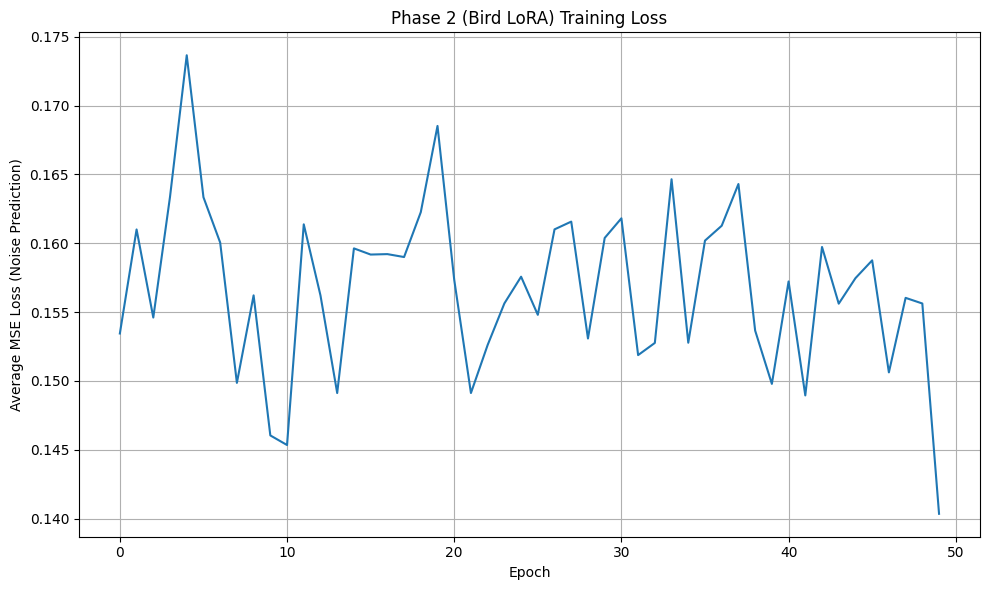

In [125]:
import matplotlib.pyplot as plt
import json
import os

# --- File Paths ---
LOSS_FILE_PATH = os.path.join(DRIVE_PROJECT_ROOT, "bird_lora_loss_history.json")
LOSS_PLOT_PATH = os.path.join(DRIVE_PROJECT_ROOT, "bird_lora_loss_curve.png")

# --- Load the loss data from the file ---
try:
    with open(LOSS_FILE_PATH, 'r') as f:
        epoch_losses = json.load(f)
except FileNotFoundError:
    print("Loss file not found. Did the training run?")
    epoch_losses = []
except Exception as e:
    print(f"Error loading loss file: {e}")
    epoch_losses = []

if epoch_losses:
    # --- Create the plot ---
    plt.figure(figsize=(10, 6))
    plt.plot(epoch_losses, linestyle='-')
    plt.title("Phase 2 (Bird LoRA) Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Average MSE Loss (Noise Prediction)")
    plt.grid(True)
    plt.tight_layout()

    # Save the plot
    plt.savefig(LOSS_PLOT_PATH)
    print(f"Loss curve plot saved to {LOSS_PLOT_PATH}")
else:
    print("No loss data to plot.")

# Phase 3: Inference

I will be comparing **MLP + Frozen SD**  and **MLP + LoRA SD**

In [64]:
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt
import soundfile as sf
from IPython.display import Audio, display

print("="*70)
print("COMPARISON TEST: FROZEN SD vs LoRA SD")
print("="*70)

COMPARISON TEST: FROZEN SD vs LoRA SD


In [14]:
print("\n1. Loading custom bird audio from Drive...")

# Path to bird sound folder
BIRD_FOLDER = os.path.join(DRIVE_PROJECT_ROOT, "bird sound for inference")

print(f"  Looking in: {BIRD_FOLDER}")

# Check if folder exists
if not os.path.exists(BIRD_FOLDER):
    print(f"⚠️ Folder not found! Please check the path.")
    print(f"   Current path: {BIRD_FOLDER}")
    audio_tensor = None
    caption_text = None
else:
    print("✓ Folder found!")

    # List all files in the folder
    files = os.listdir(BIRD_FOLDER)
    print(f"  Files in folder: {files}")

    # Find audio file
    audio_extensions = ['.wav', '.mp3', '.flac', '.ogg', '.m4a']
    audio_file = None
    for f in files:
        if any(f.lower().endswith(ext) for ext in audio_extensions):
            audio_file = f
            break

    # Find caption file
    caption_file = None
    for f in files:
        if f.lower().endswith('.txt'):
            caption_file = f
            break

    if audio_file:
        print(f"  Audio file: {audio_file}")
        audio_path = os.path.join(BIRD_FOLDER, audio_file)
    else:
        print("  ⚠️ No audio file found!")
        audio_path = None

    if caption_file:
        print(f"  Caption file: {caption_file}")
        caption_path = os.path.join(BIRD_FOLDER, caption_file)
        with open(caption_path, 'r', encoding='utf-8') as f:
            caption_text = f.read().strip()
        print(f"  Caption: {caption_text}")
    else:
        print("  ⚠️ No caption file found, using default")
        caption_text = "A bird chirping"

    # Load audio
    if audio_path and os.path.exists(audio_path):
        waveform, sr = sf.read(audio_path, dtype='float32')

        # Convert to mono if stereo
        if waveform.ndim > 1:
            waveform = waveform.mean(axis=1)

        # Resample to 48kHz if needed
        target_sr = 48000
        if sr != target_sr:
            print(f"  Resampling from {sr}Hz to {target_sr}Hz...")
            waveform = librosa.resample(waveform, orig_sr=sr, target_sr=target_sr)
            sr = target_sr

        audio_tensor = torch.tensor(waveform)

        print(f"✓ Bird audio loaded")
        print(f"  Shape: {audio_tensor.shape}")
        print(f"  Duration: {len(audio_tensor)/sr:.2f}s")
    else:
        print("\n⚠️ Could not load audio file!")
        audio_tensor = None


1. Loading custom bird audio from Drive...
  Looking in: /content/drive/MyDrive/audio_to_image_project/Bird sound for inference
✓ Folder found!
  Files in folder: ['XC1036355 - Baltimore Oriole - Icterus galbula.mp3', 'XC1036355 - Baltimore Oriole - Icterus galbula.txt']
  Audio file: XC1036355 - Baltimore Oriole - Icterus galbula.mp3
  Caption file: XC1036355 - Baltimore Oriole - Icterus galbula.txt
  Caption: baltimore orioles bird chirping
✓ Bird audio loaded
  Shape: torch.Size([521856])
  Duration: 10.87s


In [15]:
print("\n2. Loading MLP adapter...")
MLP_SAVE_PATH = os.path.join(DRIVE_PROJECT_ROOT, "MLP.pth")

mlp_adapter = MlpAdapter(input_dim=512, output_dim=768).to(device)
checkpoint = torch.load(MLP_SAVE_PATH, map_location=device)
mlp_adapter.load_state_dict(checkpoint['model_state_dict'])
mlp_adapter.eval()

print("MLP loaded")
print(f"Final similarity: {checkpoint['similarity']:.3f}")


2. Loading MLP adapter...
MLP loaded
Final similarity: 0.820


In [16]:
print("\n3. Checking CLAP model...")
if 'clap_model' not in locals() or 'clap_processor' not in locals():
    print("⚠️ CLAP not found, loading...")
    from transformers import ClapModel, AutoProcessor
    clap_model = ClapModel.from_pretrained("laion/clap-htsat-fused").to(device)
    clap_processor = AutoProcessor.from_pretrained("laion/clap-htsat-fused")
    clap_model.eval()
    for param in clap_model.parameters():
        param.requires_grad = False
    print("✓ CLAP loaded")
else:
    print("✓ CLAP already loaded")


3. Checking CLAP model...
✓ CLAP already loaded


In [17]:
@torch.no_grad()
def generate_image(audio_tensor, sd_pipeline, base_prompt="A photo of",
                   guidance_scale=7.5, num_steps=50):
    """
    Generate image using: Audio → CLAP → MLP → SD Pipeline
    """
    # Convert audio tensor to numpy
    audio_numpy = audio_tensor.numpy()

    # Process audio with CLAP
    audio_inputs = clap_processor(
        audios=[audio_numpy],
        sampling_rate=48000,
        return_tensors="pt",
        padding=True
    )
    audio_inputs = {k: v.to(device) for k, v in audio_inputs.items()}

    # Get audio embeddings from CLAP
    audio_embeddings = clap_model.get_audio_features(**audio_inputs)

    # Project to SD space using NEW trained MLP
    soft_token = mlp_adapter(audio_embeddings)

    # Tokenize base prompt
    text_inputs = sd_pipeline.tokenizer(
        base_prompt,
        padding="max_length",
        max_length=sd_pipeline.tokenizer.model_max_length,
        truncation=True,
        return_tensors="pt"
    ).to(device)

    # Get text encoder embeddings
    text_encoder_output = sd_pipeline.text_encoder(text_inputs.input_ids)[0]

    # Insert audio soft token
    attention_mask = text_inputs.attention_mask[0]
    last_token_pos = attention_mask.nonzero(as_tuple=False).max().item()

    if last_token_pos + 1 < text_encoder_output.shape[1]:
        text_encoder_output[0, last_token_pos + 1:last_token_pos + 2, :] = soft_token
    else:
        text_encoder_output[0, last_token_pos:last_token_pos + 1, :] = soft_token

    # Generate image
    image = sd_pipeline(
        prompt_embeds=text_encoder_output,
        num_inference_steps=num_steps,
        guidance_scale=guidance_scale
    ).images[0]

    return image


GENERATING IMAGES

4. Loading FROZEN Stable Diffusion...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


✓ Frozen SD loaded

5. Generating image with FROZEN SD...
   Caption: baltimore orioles bird chirping


  0%|          | 0/50 [00:00<?, ?it/s]

...

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
No LoRA keys associated to UNet2DConditionModel found with the prefix='unet'. This is safe to ignore if LoRA state dict didn't originally have any UNet2DConditionModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/is

✓ LoRA SD loaded

7. Generating image with LORA SD...
   Caption: baltimore orioles bird chirping


  0%|          | 0/50 [00:00<?, ?it/s]

✓ LoRA SD image generated

AUDIO PLAYBACK

🔊 Click play to hear the input bird audio:




DISPLAYING COMPARISON

✓ Comparison saved to /content/drive/MyDrive/audio_to_image_project/comparison_frozen_vs_lora.png
✓ Individual images saved:
  Frozen SD: /content/drive/MyDrive/audio_to_image_project/bird_frozen_sd.png
  LoRA SD: /content/drive/MyDrive/audio_to_image_project/bird_lora_sd.png


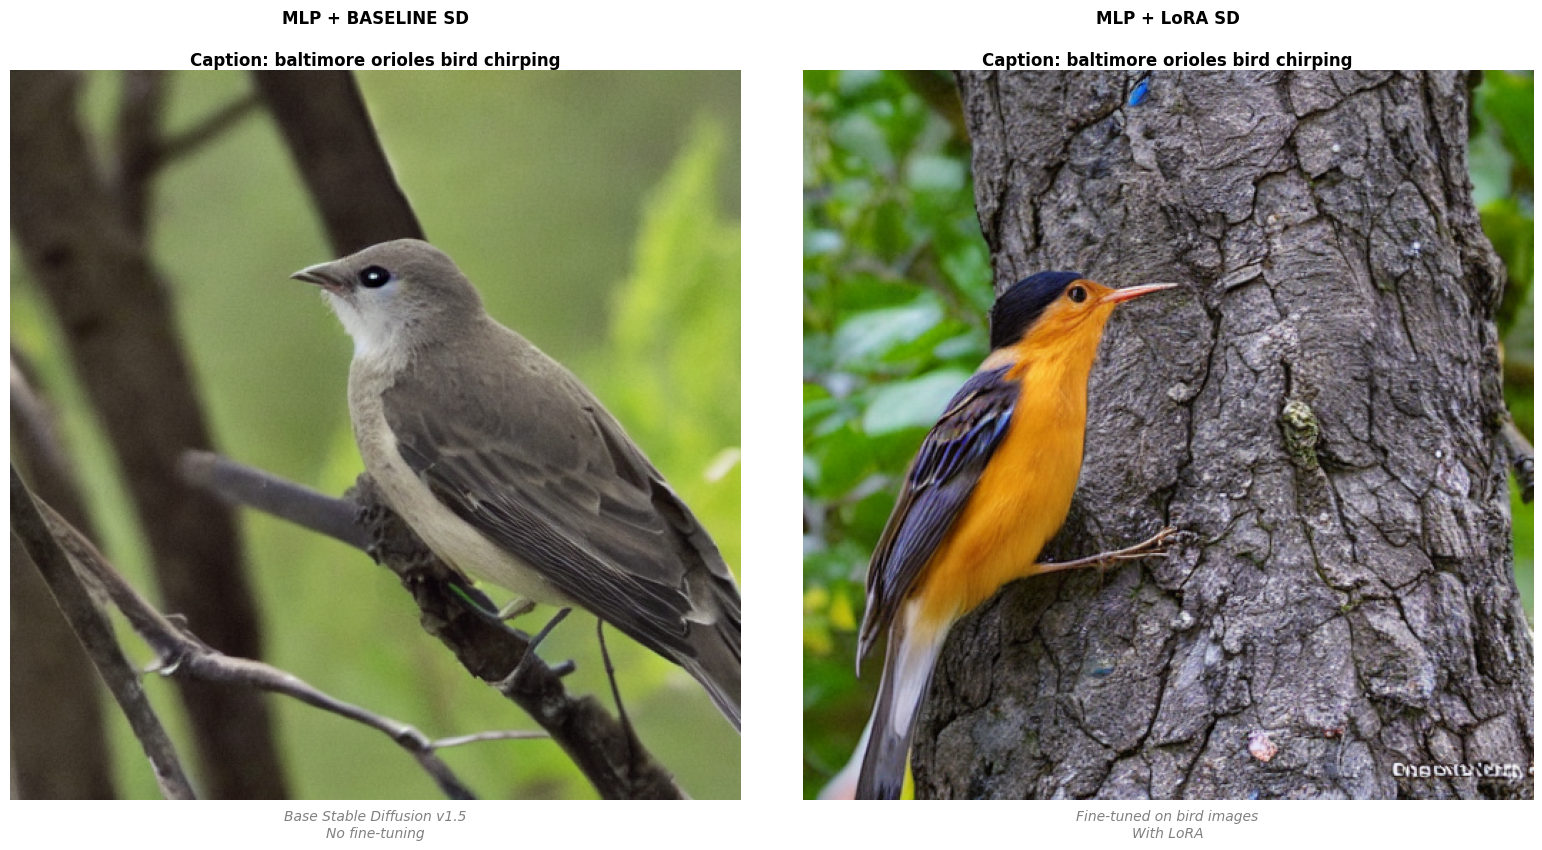


COMPARISON COMPLETED!

Pipelines tested:
  LEFT:  Bird Audio → CLAP → MLP → Baseline SD
  RIGHT: Bird Audio → CLAP → MLP → LoRA SD

Audio file: XC1036355 - Baltimore Oriole - Icterus galbula.mp3
Caption: baltimore orioles bird chirping
MLP similarity: 0.820

🔊 Scroll up to play the audio!


In [58]:
if audio_tensor is not None:
    print("\n" + "="*70)
    print("GENERATING IMAGES")
    print("="*70)

    print("\n4. Loading FROZEN Stable Diffusion...")
    SD_MODEL_ID = "runwayml/stable-diffusion-v1-5"

    pipe_frozen = StableDiffusionPipeline.from_pretrained(
        SD_MODEL_ID,
        torch_dtype=torch.float16,
        safety_checker=None
    ).to(device)

    print("✓ Frozen SD loaded")

    print("\n5. Generating image with FROZEN SD...")
    print(f"   Caption: {caption_text}")

    try:
        image_frozen = generate_image(
            audio_tensor,
            pipe_frozen,
            base_prompt="A photo of",
            guidance_scale=7.5,
            num_steps=50
        )
        print("✓ Frozen SD image generated")
    except Exception as e:
        print(f"✗ Error: {e}")
        image_frozen = None


    # ============================================================================
    # 6. GENERATE WITH LoRA SD
    # ============================================================================

    print("\n6. Loading LORA Stable Diffusion...")
    LORA_SAVE_PATH = os.path.join(DRIVE_PROJECT_ROOT, "bird_specialist_lora.safetensors")

    pipe_lora = StableDiffusionPipeline.from_pretrained(
        SD_MODEL_ID,
        torch_dtype=torch.float16,
        safety_checker=None
    ).to(device)

    try:
        pipe_lora.load_lora_weights(LORA_SAVE_PATH)
        print("✓ LoRA SD loaded")
    except Exception as e:
        print(f"⚠️ Could not load LoRA: {e}")

    print("\n7. Generating image with LORA SD...")
    print(f"   Caption: {caption_text}")

    try:
        image_lora = generate_image(
            audio_tensor,
            pipe_lora,
            base_prompt="A photo of",
            guidance_scale=7.5,
            num_steps=50
        )
        print("✓ LoRA SD image generated")
    except Exception as e:
        print(f"✗ Error: {e}")
        image_lora = None


    # ============================================================================
    # 7. DISPLAY AUDIO PLAYBACK
    # ============================================================================

    print("\n" + "="*70)
    print("AUDIO PLAYBACK")
    print("="*70)
    print("\n🔊 Click play to hear the input bird audio:\n")

    # Display audio player
    display(Audio(audio_path, autoplay=False))


    # ============================================================================
    # 8. DISPLAY SIDE-BY-SIDE COMPARISON
    # ============================================================================

    print("\n" + "="*70)
    print("DISPLAYING COMPARISON")
    print("="*70)

    if image_frozen is not None and image_lora is not None:
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))

        # Frozen SD
        axes[0].imshow(image_frozen)
        axes[0].set_title(f"MLP + BASELINE SD\n\nCaption: {caption_text}",
                         fontsize=12, wrap=True, fontweight='bold')
        axes[0].axis('off')
        axes[0].text(0.5, -0.05, 'Base Stable Diffusion v1.5\nNo fine-tuning',
                    transform=axes[0].transAxes, ha='center', fontsize=10,
                    style='italic', color='gray')

        # LoRA SD
        axes[1].imshow(image_lora)
        axes[1].set_title(f"MLP + LoRA SD\n\nCaption: {caption_text}",
                         fontsize=12, wrap=True, fontweight='bold')
        axes[1].axis('off')
        axes[1].text(0.5, -0.05, 'Fine-tuned on bird images\nWith LoRA',
                    transform=axes[1].transAxes, ha='center', fontsize=10,
                    style='italic', color='gray')

        plt.tight_layout()

        # Save comparison
        comparison_path = os.path.join(DRIVE_PROJECT_ROOT, "comparison_frozen_vs_lora.png")
        plt.savefig(comparison_path, dpi=150, bbox_inches='tight')
        print(f"\n✓ Comparison saved to {comparison_path}")

        # Also save individual images
        frozen_path = os.path.join(DRIVE_PROJECT_ROOT, "bird_frozen_sd.png")
        lora_path = os.path.join(DRIVE_PROJECT_ROOT, "bird_lora_sd.png")
        image_frozen.save(frozen_path)
        image_lora.save(lora_path)
        print(f"✓ Individual images saved:")
        print(f"  Frozen SD: {frozen_path}")
        print(f"  LoRA SD: {lora_path}")

        plt.show()

        print("\n" + "="*70)
        print("COMPARISON COMPLETED!")
        print("="*70)
        print(f"\nPipelines tested:")
        print(f"  LEFT:  Bird Audio → CLAP → MLP → Baseline SD")
        print(f"  RIGHT: Bird Audio → CLAP → MLP → LoRA SD")
        print(f"\nAudio file: {audio_file}")
        print(f"Caption: {caption_text}")
        print(f"MLP similarity: {checkpoint['similarity']:.3f}")
        print(f"\n🔊 Scroll up to play the audio!")
        print("="*70)

    else:
        print("⚠️ Could not generate both images for comparison")

else:
    print("\n⚠️ Cannot generate images - no valid audio file loaded")

# Phase 4: CLIP Evaluation

In [59]:
print("\n" + "="*70)
print("EVALUATING WITH CLIP SCORE")
print("="*70)

# Load CLIP model for evaluation
print("\n1. Loading CLIP model for evaluation...")
from transformers import CLIPProcessor, CLIPModel

CLIP_EVAL_MODEL = "openai/clip-vit-large-patch14"
clip_eval_model = CLIPModel.from_pretrained(CLIP_EVAL_MODEL).to(device)
clip_eval_processor = CLIPProcessor.from_pretrained(CLIP_EVAL_MODEL)

clip_eval_model.eval()
for param in clip_eval_model.parameters():
    param.requires_grad = False

print("✓ CLIP evaluation model loaded")


EVALUATING WITH CLIP SCORE

1. Loading CLIP model for evaluation...
✓ CLIP evaluation model loaded


In [60]:
@torch.no_grad()
def calculate_clip_score(image, caption, model, processor):
    """
    Calculate CLIP score between generated image and text caption
    Returns: clip_score (0-100), cosine_similarity (0-1)
    """
    # Process image
    image_inputs = processor(images=image, return_tensors="pt").to(device)
    image_features = model.get_image_features(**image_inputs)
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    # Process text
    text_inputs = processor(text=caption, return_tensors="pt", padding=True).to(device)
    text_features = model.get_text_features(**text_inputs)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    # Calculate cosine similarity
    similarity = (image_features @ text_features.T).squeeze().item()
    clip_score = 100 * similarity

    return clip_score, similarity

In [61]:
print("\n2. Calculating CLIP scores...")
print(f"   Caption: '{caption_text}'")

results = {}

if image_frozen is not None:
    frozen_score, frozen_sim = calculate_clip_score(
        image_frozen,
        caption_text,
        clip_eval_model,
        clip_eval_processor
    )
    results['frozen'] = {'score': frozen_score, 'similarity': frozen_sim}
    print(f"\n   ✓ Frozen SD CLIP Score: {frozen_score:.2f}")
    print(f"     Cosine Similarity: {frozen_sim:.4f}")
else:
    print("\n   ✗ Frozen SD image not available")

if image_lora is not None:
    lora_score, lora_sim = calculate_clip_score(
        image_lora,
        caption_text,
        clip_eval_model,
        clip_eval_processor
    )
    results['lora'] = {'score': lora_score, 'similarity': lora_sim}
    print(f"\n   ✓ LoRA SD CLIP Score: {lora_score:.2f}")
    print(f"     Cosine Similarity: {lora_sim:.4f}")
else:
    print("\n   ✗ LoRA SD image not available")


2. Calculating CLIP scores...
   Caption: 'baltimore orioles bird chirping'

   ✓ Frozen SD CLIP Score: 15.43
     Cosine Similarity: 0.1543

   ✓ LoRA SD CLIP Score: 25.82
     Cosine Similarity: 0.2582


In [62]:
print("\n" + "="*70)
print("EVALUATION RESULTS SUMMARY")
print("="*70)

if 'frozen' in results and 'lora' in results:
    improvement = results['lora']['score'] - results['frozen']['score']
    improvement_pct = (improvement / results['frozen']['score']) * 100

    print(f"\n📊 CLIP Score Comparison:")
    print(f"   Baseline SD:  {results['frozen']['score']:.2f}")
    print(f"   LoRA SD:      {results['lora']['score']:.2f}")
    print(f"   Improvement:  {improvement:+.2f} ({improvement_pct:+.1f}%)")

    print(f"\n📈 Cosine Similarity Comparison:")
    print(f"   Baseline SD:  {results['frozen']['similarity']:.4f}")
    print(f"   LoRA SD:      {results['lora']['similarity']:.4f}")

    print(f"\n🎯 Interpretation:")
    if results['lora']['score'] > results['frozen']['score']:
        print(f"   ✓ LoRA fine-tuning improved image-text alignment!")
    elif results['lora']['score'] < results['frozen']['score']:
        print(f"   ⚠️ LoRA fine-tuning decreased alignment (may need more training)")
    else:
        print(f"   → No significant difference between models")

    print(f"\n📋 CLIP Score Reference:")
    print(f"   20-30: Weak alignment")
    print(f"   30-35: Decent alignment (typical for audio-to-image)")
    print(f"   35-40: Good alignment")
    print(f"   40+:   Strong alignment")


EVALUATION RESULTS SUMMARY

📊 CLIP Score Comparison:
   Baseline SD:  15.43
   LoRA SD:      25.82
   Improvement:  +10.39 (+67.3%)

📈 Cosine Similarity Comparison:
   Baseline SD:  0.1543
   LoRA SD:      0.2582

🎯 Interpretation:
   ✓ LoRA fine-tuning improved image-text alignment!

📋 CLIP Score Reference:
   20-30: Weak alignment
   30-35: Decent alignment (typical for audio-to-image)
   35-40: Good alignment
   40+:   Strong alignment



3. Creating annotated comparison...
✓ Annotated comparison saved to /content/drive/MyDrive/audio_to_image_project/evaluation_with_clip_scores.png


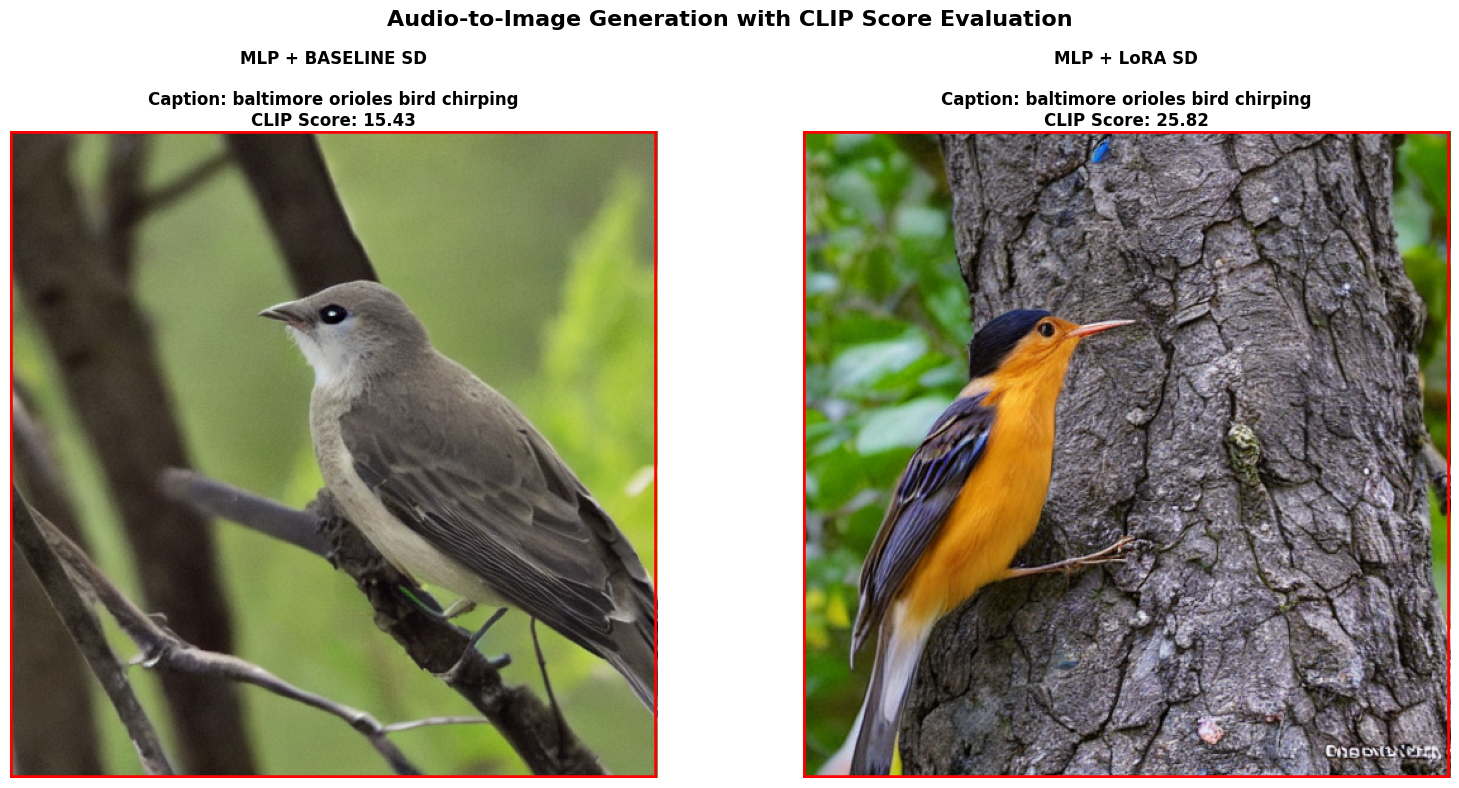

In [63]:
if image_frozen is not None and image_lora is not None:
    print("\n3. Creating annotated comparison...")

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    # Add main title at the top
    fig.suptitle("Audio-to-Image Generation with CLIP Score Evaluation",
                 fontsize=16, fontweight='bold', y=0.98)

    # Frozen SD with score
    axes[0].imshow(image_frozen)
    frozen_title = f"MLP + BASELINE SD\n\n"
    frozen_title += f"Caption: {caption_text}\n"
    frozen_title += f"CLIP Score: {results['frozen']['score']:.2f}"
    axes[0].set_title(frozen_title, fontsize=12, wrap=True, fontweight='bold')
    axes[0].axis('off')

    # Add color-coded border based on score
    frozen_color = 'green' if results['frozen']['score'] > 35 else 'orange' if results['frozen']['score'] > 30 else 'red'
    axes[0].add_patch(plt.Rectangle((0, 0), 1, 1, transform=axes[0].transAxes,
                                    fill=False, edgecolor=frozen_color, linewidth=4))

    # LoRA SD with score
    axes[1].imshow(image_lora)
    lora_title = f"MLP + LoRA SD\n\n"
    lora_title += f"Caption: {caption_text}\n"
    lora_title += f"CLIP Score: {results['lora']['score']:.2f}"
    axes[1].set_title(lora_title, fontsize=12, wrap=True, fontweight='bold')
    axes[1].axis('off')

    # Add color-coded border
    lora_color = 'green' if results['lora']['score'] > 35 else 'orange' if results['lora']['score'] > 30 else 'red'
    axes[1].add_patch(plt.Rectangle((0, 0), 1, 1, transform=axes[1].transAxes,
                                    fill=False, edgecolor=lora_color, linewidth=4))

    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for main title

    # Save annotated comparison
    eval_comparison_path = os.path.join(DRIVE_PROJECT_ROOT, "evaluation_with_clip_scores.png")
    plt.savefig(eval_comparison_path, dpi=150, bbox_inches='tight')
    print(f"✓ Annotated comparison saved to {eval_comparison_path}")

    plt.show()